# PEFT / LoRA fine-tuning: ViT for weather classification
Learning notebook — run cell by cell.

In [1]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = "./weather_raw/raw/image_folders/auto/dataset"
classes = sorted(d for d in os.listdir(DATA_DIR) if not d.startswith("."))
print("Classes found:", classes)

Classes found: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [2]:
from datasets import load_dataset

full_ds = load_dataset("imagefolder", data_dir=DATA_DIR)["train"]
split_ds = full_ds.train_test_split(test_size=0.2, seed=42, stratify_by_column="label")
train_ds, eval_ds = split_ds["train"], split_ds["test"]

label_names = train_ds.features["label"].names
print(f"Train: {len(train_ds)} images | Eval: {len(eval_ds)} images")
print("Labels:", label_names)

/Users/enkay/Documents/Claude/hf-cv-demo/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Resolving data files:   0%|          | 0/660 [00:00<?, ?it/s]

Train: 528 images | Eval: 132 images
Labels: ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


In [3]:
counts_df = (
    pd.DataFrame({"label": [label_names[l] for l in train_ds["label"]]})
    .value_counts()
    .rename("train_count")
    .reset_index()
)
eval_counts = pd.Series([label_names[l] for l in eval_ds["label"]]).value_counts()
counts_df["eval_count"] = counts_df["label"].map(eval_counts)
counts_df = counts_df.sort_values("label").reset_index(drop=True)
counts_df

,label,train_count,eval_count
0,dew,48,12
1,fogsmog,48,12
2,frost,48,12
3,glaze,48,12
4,hail,48,12
5,lightning,48,12
6,rain,48,12
7,rainbow,48,12
8,rime,48,12
9,sandstorm,48,12


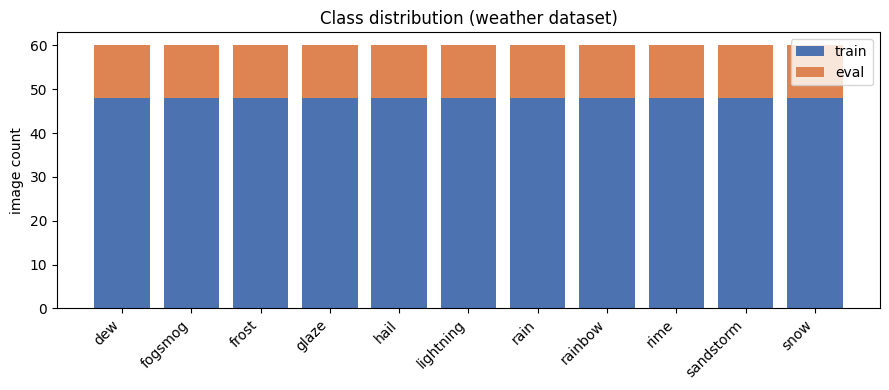

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(counts_df["label"], counts_df["train_count"], color="#4C72B0", label="train")
ax.bar(counts_df["label"], counts_df["eval_count"], bottom=counts_df["train_count"], color="#DD8452", label="eval")
ax.set_ylabel("image count")
ax.set_title("Class distribution (weather dataset)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

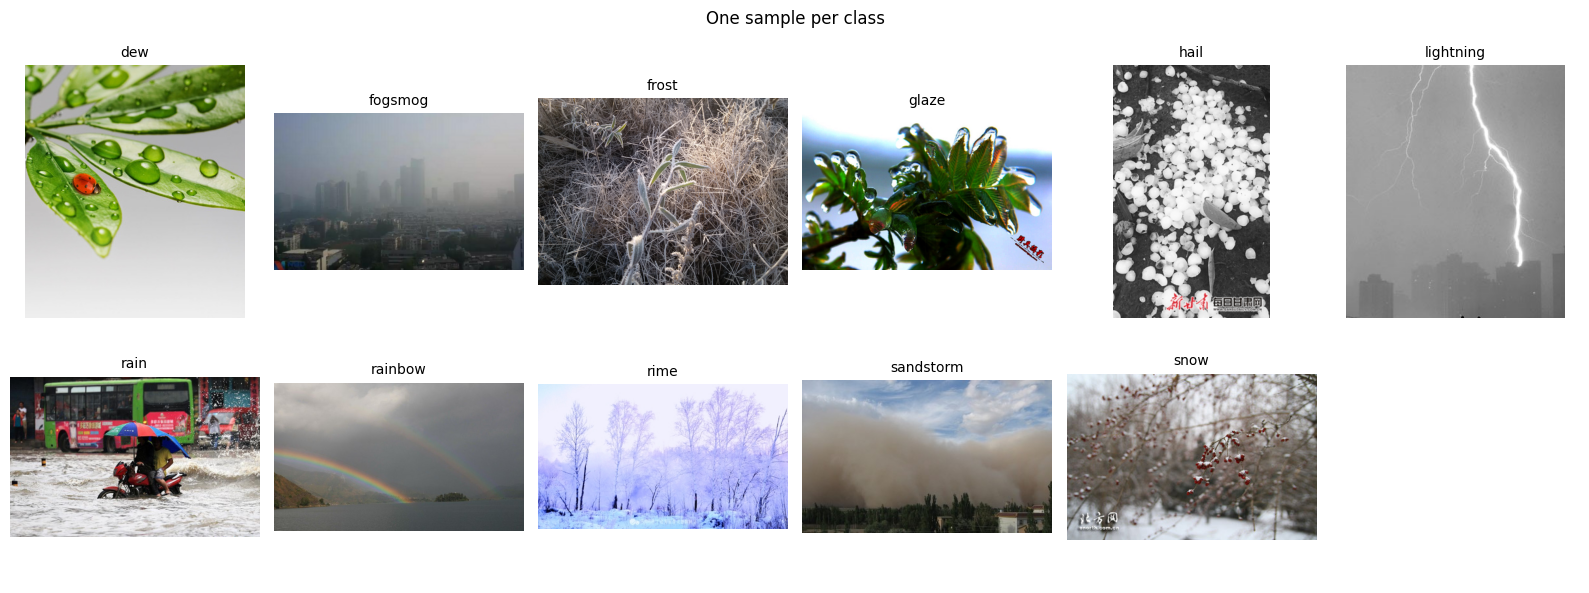

In [5]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
random.seed(0)
for ax, cls in zip(axes.flat, label_names):
    paths = glob.glob(os.path.join(DATA_DIR, cls, "*"))
    img = Image.open(random.choice(paths)).convert("RGB")
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(label_names):]:
    ax.axis("off")
plt.suptitle("One sample per class")
plt.tight_layout()
plt.show()

## Load the pretrained ViT and swap its head

`google/vit-base-patch16-224` was trained on 1000 ImageNet classes. We load it with
`num_labels=11` so Transformers replaces the final classification layer with a fresh,
randomly-initialized 11-way head (the mismatched-size original head is dropped).

In [6]:
import torch
from transformers import AutoImageProcessor, AutoModelForImageClassification

MODEL_NAME = "google/vit-base-patch16-224"

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

id2label = {i: l for i, l in enumerate(label_names)}
label2id = {l: i for i, l in enumerate(label_names)}

base_model = AutoModelForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
print(base_model.classifier)

Using device: mps


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([11]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([11, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Linear(in_features=768, out_features=11, bias=True)


## Attach LoRA adapters

We freeze the backbone and inject small trainable low-rank matrices into the attention
`query`/`value` projections (`r=8`). The new classifier head is also kept fully trainable
via `modules_to_save`, since it has no pretrained knowledge to preserve.

In [7]:
from peft import LoraConfig, get_peft_model

full_params = sum(p.numel() for p in base_model.parameters())

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query", "value"],
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["classifier"],
)
model = get_peft_model(base_model, lora_config).to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = full_params - trainable_params

print(f"Total params:     {full_params:,}")
print(f"Trainable params: {trainable_params:,} ({100*trainable_params/full_params:.2f}%)")
print(f"Frozen params:    {frozen_params:,}")

Total params:     85,807,115
Trainable params: 303,371 (0.35%)
Frozen params:    85,503,744


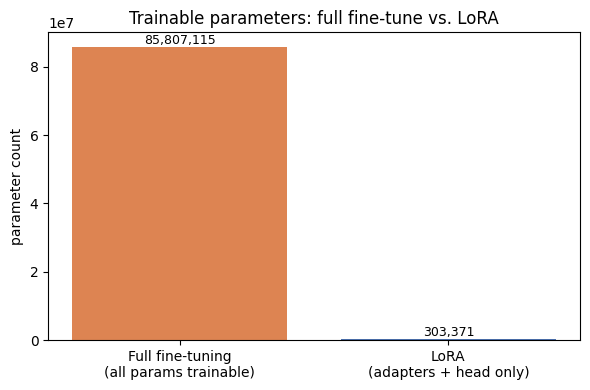

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Full fine-tuning\n(all params trainable)", "LoRA\n(adapters + head only)"],
       [full_params, trainable_params],
       color=["#DD8452", "#4C72B0"])
ax.set_ylabel("parameter count")
ax.set_title("Trainable parameters: full fine-tune vs. LoRA")
for i, v in enumerate([full_params, trainable_params]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

## Preprocess + train

We wrap each image with the ViT processor (resize/normalize) on the fly, then fine-tune
with Hugging Face's `Trainer`. Only the LoRA adapters + classifier head receive gradients.

In [9]:
def transform(batch):
    images = [img.convert("RGB") for img in batch["image"]]
    inputs = processor(images=images, return_tensors="pt")
    inputs["labels"] = batch["label"]
    return inputs

train_ds.set_transform(transform)
eval_ds.set_transform(transform)

def collate_fn(batch):
    pixel_values = torch.stack([torch.as_tensor(b["pixel_values"]) for b in batch])
    labels = torch.tensor([b["labels"] for b in batch])
    return {"pixel_values": pixel_values, "labels": labels}

print("Transforms attached.")

Transforms attached.


In [10]:
import numpy as np
from transformers import TrainingArguments, Trainer

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}

args = TrainingArguments(
    output_dir="./vit-weather-lora",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=6,
    learning_rate=5e-4,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=5,
    remove_unused_columns=False,
    report_to=[],
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=eval_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()

/Users/enkay/Documents/Claude/hf-cv-demo/.venv/lib/python3.9/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.996200,0.866993,0.780303
2,0.437600,0.487480,0.856061
3,0.260500,0.376476,0.863636
4,0.150900,0.375165,0.856061
5,0.087300,0.343747,0.878788
6,0.026400,0.341560,0.878788
